# Análise Exploratória de Dados (EDA) - Base IMP 2024

## Objetivo
Realizar uma análise exploratória completa dos dados de importação brasileira de 2024, seguindo as melhores práticas de data science para:
- Ingestão e estruturação dos dados
- Limpeza e tratamento de inconsistências
- Criação de banco de dados SQLite
- Preparação para análises futuras

## Dataset
- **IMP_2024.csv**: Dados de importações brasileiras de 2024
- **TABELAS_AUXILIARES.xlsx**: Tabelas de apoio com códigos e descrições

## 0. Imports e Funções Auxiliares

In [1]:
import csv
import pandas as pd
import sqlite3
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import warnings
import os
from pathlib import Path

# Configurações
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

In [2]:
def fetch(query, conn, formatted=True):
    """Execute query e retorna resultados em DataFrame ou lista"""
    cur = conn.cursor()
    cur.execute(query)
    rs = cur.fetchall()
    
    # extrair nomes das colunas
    columns = [desc[0] for desc in cur.description]
    
    return pd.DataFrame(rs, columns=columns) if formatted else rs

def show_tables(conn):
    """Lista todas as tabelas do banco"""
    return [x[0] for x in fetch('SELECT tbl_name FROM sqlite_master WHERE type="table"', conn, False)]

def shape(table, conn):
    """Retorna formato da tabela (linhas, colunas)"""
    nrows = fetch(f'SELECT COUNT(*) FROM {table}', conn, False)[0][0]
    ncols = fetch(f'SELECT COUNT(*) FROM pragma_table_info("{table}")', conn, False)[0][0]
    return (nrows, ncols)

def desc(table, conn):
    """Lista colunas da tabela"""
    cur = conn.cursor()
    cur.execute(f'PRAGMA table_info("{table}")')
    columns = [row[1] for row in cur.fetchall()]
    return columns

def info(table, conn):
    """Informações detalhadas da tabela (tipo pandas.info())"""
    # informações das colunas
    df1 = fetch(f'PRAGMA table_info("{table}")', conn)
    columns = desc(table, conn)
    
    # contagem total por coluna
    counts = ', '.join([f'COUNT(*) AS "{column}"' for column in columns])
    df2 = fetch(f'SELECT {counts} FROM "{table}"', conn).transpose()
    df2.columns = ['count']
    
    # contagem não-nula por coluna
    counts = ', '.join([f'COUNT("{column}") AS "{column}"' for column in columns])
    df3 = fetch(f'SELECT {counts} FROM "{table}"', conn).transpose()
    df3.columns = ['notnull_count']

    # contagem valores únicos por coluna
    counts = ', '.join([f'COUNT(DISTINCT "{column}") AS "{column}"' for column in columns])
    df4 = fetch(f'SELECT {counts} FROM "{table}"', conn).transpose()
    df4.columns = ['unique_count']
    
    return df1.merge(df2, left_on='name', right_index=True) \
            .merge(df3, left_on='name', right_index=True) \
            .merge(df4, left_on='name', right_index=True)

def hist_sql(data, xlabel='', ylabel='', bins='auto', title=''):
    """Cria histograma a partir de dados SQL"""
    df = pd.DataFrame(data, columns=['key', 'frequency'])
    expanded = df.loc[df.index.repeat(df['frequency'])].reset_index(drop=True)
    
    plt.figure(figsize=(12, 6))
    sns.histplot(expanded['key'], bins=bins, kde=False)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def memory_usage(df):
    """Calcula uso de memória do DataFrame"""
    return f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB"

## 1. Análise Inicial dos Dados

Primeiro, vamos examinar a estrutura dos arquivos disponíveis e entender o que temos.

In [3]:
# Verificar arquivos disponíveis no diretório data
data_dir = Path('data')
files = list(data_dir.glob('*'))

print("Arquivos encontrados no diretório 'data':")
for file in files:
    size_mb = file.stat().st_size / (1024**2)
    print(f"  - {file.name}: {size_mb:.1f} MB")

print(f"\nTotal de arquivos: {len(files)}")

Arquivos encontrados no diretório 'data':
  - IMP_2024.csv: 159.0 MB
  - TABELAS_AUXILIARES.xlsx: 5.3 MB

Total de arquivos: 2


In [4]:
# Analisar o arquivo principal CSV
csv_file = 'data/IMP_2024.csv'

print("=== ANÁLISE PRELIMINAR DO CSV ===\n")

# Ler apenas as primeiras linhas para entender a estrutura
try:
    # Detectar encoding
    with open(csv_file, 'rb') as f:
        sample = f.read(10000)
    
    # Tentar diferentes encodings
    encodings = ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']
    encoding_usado = None
    
    for enc in encodings:
        try:
            sample.decode(enc)
            encoding_usado = enc
            print(f"✅ Encoding detectado: {enc}")
            break
        except UnicodeDecodeError:
            continue
    
    if not encoding_usado:
        encoding_usado = 'latin-1'  # fallback
        print(f"⚠️  Usando encoding fallback: {encoding_usado}")
    
    # Detectar delimitador analisando primeira linha
    with open(csv_file, 'r', encoding=encoding_usado) as f:
        first_line = f.readline().strip()
        
    print(f"\n🔍 PRIMEIRA LINHA (amostra):")
    print(f"   {first_line[:100]}...")
    
    # Detectar delimitador
    if first_line.count(';') > first_line.count(','):
        delimiter = ';'
        print(f"📝 Delimitador detectado: ponto-e-vírgula (;)")
    else:
        delimiter = ','
        print(f"📝 Delimitador detectado: vírgula (,)")
    
    # Ler primeiras 5 linhas com delimitador correto
    df_sample = pd.read_csv(csv_file, 
                           encoding=encoding_usado, 
                           delimiter=delimiter,
                           quotechar='"',
                           nrows=5)
    
    print(f"\n📊 ESTRUTURA INICIAL:")
    print(f"   - Colunas: {len(df_sample.columns)}")
    print(f"   - Primeiras 5 linhas carregadas com sucesso")
    print(f"   - Encoding: {encoding_usado}")
    print(f"   - Delimitador: {delimiter}")
    
    print(f"\n📋 COLUNAS ENCONTRADAS:")
    for i, col in enumerate(df_sample.columns, 1):
        col_clean = col.strip().replace('"', '')
        print(f"   {i:2d}. {col_clean}")
    
    print(f"\n🔍 AMOSTRA DOS DADOS:")
    display(df_sample.head(3))
    
except Exception as e:
    print(f"❌ Erro ao ler o arquivo: {e}")
    print("Tentaremos uma abordagem alternativa...")

=== ANÁLISE PRELIMINAR DO CSV ===

✅ Encoding detectado: utf-8

🔍 PRIMEIRA LINHA (amostra):
   "CO_ANO";"CO_MES";"CO_NCM";"CO_UNID";"CO_PAIS";"SG_UF_NCM";"CO_VIA";"CO_URF";"QT_ESTAT";"KG_LIQUIDO"...
📝 Delimitador detectado: ponto-e-vírgula (;)

📊 ESTRUTURA INICIAL:
   - Colunas: 13
   - Primeiras 5 linhas carregadas com sucesso
   - Encoding: utf-8
   - Delimitador: ;

📋 COLUNAS ENCONTRADAS:
    1. CO_ANO
    2. CO_MES
    3. CO_NCM
    4. CO_UNID
    5. CO_PAIS
    6. SG_UF_NCM
    7. CO_VIA
    8. CO_URF
    9. QT_ESTAT
   10. KG_LIQUIDO
   11. VL_FOB
   12. VL_FRETE
   13. VL_SEGURO

🔍 AMOSTRA DOS DADOS:


,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,VL_FRETE,VL_SEGURO
0,2024,10,84818092,11,161,SC,1,927800,344,90,6823,77,10
1,2024,4,90304090,11,249,SP,4,817700,1,9,4890,147,7
2,2024,1,39172300,10,23,PE,4,417901,1128,1128,28129,20688,7


In [5]:
# Analisar tabelas auxiliares Excel
excel_file = 'data/TABELAS_AUXILIARES.xlsx'

print("\n=== ANÁLISE DAS TABELAS AUXILIARES ===\n")

try:
    # Ler todas as abas do Excel
    excel_data = pd.read_excel(excel_file, sheet_name=None)
    
    print(f"📊 ARQUIVO: {excel_file}")
    print(f"   - Número de abas: {len(excel_data)}")
    
    print(f"\n📋 ABAS ENCONTRADAS:")
    for i, (sheet_name, df) in enumerate(excel_data.items(), 1):
        print(f"   {i}. {sheet_name}: {df.shape[0]} linhas x {df.shape[1]} colunas")
    
    # Mostrar uma amostra de cada aba
    for sheet_name, df in excel_data.items():
        print(f"\n🔍 AMOSTRA DA ABA '{sheet_name}':")
        print(f"   Colunas: {list(df.columns)}")
        if len(df) > 0:
            display(df.head(3))
        else:
            print("   (Aba vazia)")
        print("-" * 80)
        
except Exception as e:
    print(f"❌ Erro ao ler o arquivo Excel: {e}")


=== ANÁLISE DAS TABELAS AUXILIARES ===

❌ Erro ao ler o arquivo Excel: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.


## 2. Ingestão de Dados

Agora vamos criar o banco de dados SQLite e importar os dados de forma eficiente, seguindo as melhores práticas para grandes volumes de dados.

In [6]:
# Configurar banco de dados SQLite
db_name = 'importacoes_brasil_2024.db'

# Remover banco existente se houver
if os.path.exists(db_name):
    os.remove(db_name)
    print(f"🗑️  Banco existente removido: {db_name}")

# Conectar ao banco SQLite
conn = sqlite3.connect(db_name)
cur = conn.cursor()

print(f"✅ Conectado ao banco: {db_name}")

# Configurar PRAGMA para performance na ingestão
cur.execute('PRAGMA synchronous = OFF')
cur.execute('PRAGMA journal_mode = MEMORY')
cur.execute('PRAGMA temp_store = MEMORY')
cur.execute('PRAGMA cache_size = 1000000')

print("⚙️  Configurações de performance aplicadas")

✅ Conectado ao banco: importacoes_brasil_2024.db
⚙️  Configurações de performance aplicadas


In [7]:
# Importar tabelas auxiliares do Excel primeiro
print("📊 IMPORTANDO TABELAS AUXILIARES...")

try:
    excel_data = pd.read_excel('data/TABELAS_AUXILIARES.xlsx', sheet_name=None)
    
    for sheet_name, df in excel_data.items():
        if len(df) > 0:  # Só importar abas com dados
            # Limpar nome da tabela (remover caracteres especiais)
            table_name = sheet_name.replace(' ', '_').replace('-', '_').replace('(', '').replace(')', '')
            table_name = f"aux_{table_name}"
            
            # Importar para SQLite
            df.to_sql(table_name, conn, if_exists='replace', index=False)
            
            print(f"   ✅ {sheet_name} -> {table_name}: {len(df)} registros")
        else:
            print(f"   ⚠️  {sheet_name}: aba vazia, pulando...")
    
    print("✅ Tabelas auxiliares importadas com sucesso!")
    
except Exception as e:
    print(f"❌ Erro ao importar tabelas auxiliares: {e}")

📊 IMPORTANDO TABELAS AUXILIARES...
❌ Erro ao importar tabelas auxiliares: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.


In [8]:
# Importar CSV principal com delimitador correto
print("\n📊 IMPORTANDO DADOS PRINCIPAIS DE IMPORTAÇÃO (CORRIGIDO)...")

csv_file = 'data/IMP_2024.csv'
BATCH_SIZE = 10000  # Processar em lotes de 10k registros

# Remover tabela antiga se existir
cur.execute('DROP TABLE IF EXISTS importacoes')

try:
    print(f"📝 Detectado que o CSV usa ponto-e-vírgula (;) como separador")
    print(f"📝 Detectado que campos estão entre aspas")
    
    # Ler em chunks com os parâmetros corretos
    chunk_iter = pd.read_csv(csv_file, 
                             encoding='utf-8',
                             delimiter=';',  # Separador correto
                             quotechar='"',  # Caractere de aspas
                             chunksize=BATCH_SIZE,
                             low_memory=False)
    
    total_rows = 0
    batch_num = 0
    
    for chunk in chunk_iter:
        batch_num += 1
        
        # Limpar nomes das colunas (remover aspas e espaços)
        chunk.columns = chunk.columns.str.strip()
        chunk.columns = chunk.columns.str.replace('"', '')
        chunk.columns = chunk.columns.str.replace(' ', '_')
        chunk.columns = chunk.columns.str.replace('-', '_')
        chunk.columns = chunk.columns.str.replace('(', '')
        chunk.columns = chunk.columns.str.replace(')', '')
        chunk.columns = chunk.columns.str.replace('/', '_')
        
        # Primeira vez: criar tabela, depois: append
        if_exists = 'replace' if batch_num == 1 else 'append'
        
        # Inserir chunk no banco
        chunk.to_sql('importacoes', conn, if_exists=if_exists, index=False)
        
        total_rows += len(chunk)
        
        # Progress feedback
        if batch_num % 5 == 0:  # A cada 5 batches
            print(f"   📦 Processados {batch_num} lotes ({total_rows:,} registros)")
    
    print(f"✅ Importação corrigida concluída!")
    print(f"   📊 Total de registros: {total_rows:,}")
    print(f"   📦 Lotes processados: {batch_num}")
    
    # Verificar estrutura da tabela corrigida
    columns_corrected = desc('importacoes', conn)
    print(f"   📋 Colunas detectadas: {len(columns_corrected)}")
    print(f"   📋 Lista de colunas:")
    for i, col in enumerate(columns_corrected, 1):
        print(f"      {i:2d}. {col}")
    
except Exception as e:
    print(f"❌ Erro durante a importação corrigida: {e}")
    print(f"   Registros processados até o erro: {total_rows:,}")


📊 IMPORTANDO DADOS PRINCIPAIS DE IMPORTAÇÃO (CORRIGIDO)...
📝 Detectado que o CSV usa ponto-e-vírgula (;) como separador
📝 Detectado que campos estão entre aspas
   📦 Processados 5 lotes (50,000 registros)
   📦 Processados 10 lotes (100,000 registros)
   📦 Processados 15 lotes (150,000 registros)
   📦 Processados 20 lotes (200,000 registros)
   📦 Processados 25 lotes (250,000 registros)
   📦 Processados 30 lotes (300,000 registros)
   📦 Processados 35 lotes (350,000 registros)
   📦 Processados 40 lotes (400,000 registros)
   📦 Processados 45 lotes (450,000 registros)
   📦 Processados 50 lotes (500,000 registros)
   📦 Processados 55 lotes (550,000 registros)
   📦 Processados 60 lotes (600,000 registros)
   📦 Processados 65 lotes (650,000 registros)
   📦 Processados 70 lotes (700,000 registros)
   📦 Processados 75 lotes (750,000 registros)
   📦 Processados 80 lotes (800,000 registros)
   📦 Processados 85 lotes (850,000 registros)
   📦 Processados 90 lotes (900,000 registros)
   📦 Process

In [9]:
# Finalizar importação e otimizar banco
print("\n🔧 FINALIZANDO E OTIMIZANDO BANCO...")

# Commit todas as transações
conn.commit()

# Restaurar configurações normais do SQLite
cur.execute('PRAGMA synchronous = FULL')
cur.execute('PRAGMA journal_mode = DELETE')

# Executar VACUUM para otimizar espaço
print("   🗜️  Executando VACUUM para otimizar espaço...")
cur.execute('VACUUM')

# Criar índices básicos para performance
print("   📇 Criando índices...")
try:
    # Índices nas colunas mais usadas (ajustar conforme colunas reais)
    # Nota: os nomes das colunas serão conhecidos após a importação
    tables_info = show_tables(conn)
    print(f"   📋 Tabelas criadas: {tables_info}")
    
    # Obter informações da tabela principal
    if 'importacoes' in tables_info:
        columns = desc('importacoes', conn)
        print(f"   📊 Colunas da tabela principal: {len(columns)}")
        
        # Criar índices em colunas que provavelmente existem
        common_index_columns = ['pais', 'produto', 'ncm', 'mes', 'ano', 'uf']
        for col in common_index_columns:
            # Verificar se coluna existe (com variações de nome)
            possible_names = [col, col.upper(), col.lower(), f'co_{col}', f'no_{col}']
            for possible_name in possible_names:
                if possible_name in columns:
                    try:
                        cur.execute(f'CREATE INDEX IF NOT EXISTS idx_{possible_name} ON importacoes({possible_name})')
                        print(f"     ✅ Índice criado: {possible_name}")
                        break
                    except:
                        pass
    
    conn.commit()
    print("✅ Otimização concluída!")
    
except Exception as e:
    print(f"⚠️  Aviso durante otimização: {e}")

# Verificar tamanho final do banco
db_size = os.path.getsize(db_name) / (1024**2)
print(f"\n📊 ESTATÍSTICAS FINAIS:")
print(f"   💾 Tamanho do banco: {db_size:.1f} MB")
print(f"   📁 Arquivo: {db_name}")


🔧 FINALIZANDO E OTIMIZANDO BANCO...
   🗜️  Executando VACUUM para otimizar espaço...
   📇 Criando índices...
   📋 Tabelas criadas: ['importacoes']
   📊 Colunas da tabela principal: 13
✅ Otimização concluída!

📊 ESTATÍSTICAS FINAIS:
   💾 Tamanho do banco: 92.2 MB
   📁 Arquivo: importacoes_brasil_2024.db


## 3. Entendimento dos Dados

Agora que os dados estão importados, vamos explorar a estrutura e qualidade dos dados usando nossas funções auxiliares.

In [10]:
# Explorar tabelas criadas
print("📋 TABELAS DISPONÍVEIS NO BANCO:")
tables = show_tables(conn)
for i, table in enumerate(tables, 1):
    shape_info = shape(table, conn)
    print(f"   {i}. {table}: {shape_info[0]:,} linhas × {shape_info[1]} colunas")

print(f"\nTotal de tabelas: {len(tables)}")

📋 TABELAS DISPONÍVEIS NO BANCO:
   1. importacoes: 2,273,708 linhas × 13 colunas

Total de tabelas: 1


In [11]:
# Análise detalhada da tabela principal
print("🔍 ANÁLISE DA TABELA PRINCIPAL 'importacoes':\n")

# Informações gerais
table_info = info('importacoes', conn)
print("📊 INFORMAÇÕES DAS COLUNAS:")
display(table_info)

print(f"\n📈 ESTATÍSTICAS GERAIS:")
shape_info = shape('importacoes', conn)
print(f"   - Dimensões: {shape_info[0]:,} linhas × {shape_info[1]} colunas")
print(f"   - Densidade de dados: {(table_info['notnull_count'].sum() / (shape_info[0] * shape_info[1]) * 100):.1f}%")

# Verificar tipos de dados inferidos
print(f"\n🔤 TIPOS DE DADOS:")
for _, row in table_info.iterrows():
    null_pct = ((row['count'] - row['notnull_count']) / row['count'] * 100)
    unique_pct = (row['unique_count'] / row['notnull_count'] * 100) if row['notnull_count'] > 0 else 0
    print(f"   {row['name']:25} | {row['type']:10} | Nulos: {null_pct:5.1f}% | Únicos: {unique_pct:5.1f}%")

🔍 ANÁLISE DA TABELA PRINCIPAL 'importacoes':



📊 INFORMAÇÕES DAS COLUNAS:


,cid,name,type,notnull,dflt_value,pk,count,notnull_count,unique_count
0,0,CO_ANO,INTEGER,0,None,0,2273708,2273708,1
1,1,CO_MES,INTEGER,0,None,0,2273708,2273708,12
2,2,CO_NCM,INTEGER,0,None,0,2273708,2273708,8748
3,3,CO_UNID,INTEGER,0,None,0,2273708,2273708,13
4,4,CO_PAIS,INTEGER,0,None,0,2273708,2273708,239
5,5,SG_UF_NCM,TEXT,0,None,0,2273708,2273708,28
6,6,CO_VIA,INTEGER,0,None,0,2273708,2273708,10
7,7,CO_URF,INTEGER,0,None,0,2273708,2273708,87
8,8,QT_ESTAT,INTEGER,0,None,0,2273708,2273708,136545
9,9,KG_LIQUIDO,INTEGER,0,None,0,2273708,2273708,119320



📈 ESTATÍSTICAS GERAIS:
   - Dimensões: 2,273,708 linhas × 13 colunas
   - Densidade de dados: 100.0%

🔤 TIPOS DE DADOS:
   CO_ANO                    | INTEGER    | Nulos:   0.0% | Únicos:   0.0%
   CO_MES                    | INTEGER    | Nulos:   0.0% | Únicos:   0.0%
   CO_NCM                    | INTEGER    | Nulos:   0.0% | Únicos:   0.4%
   CO_UNID                   | INTEGER    | Nulos:   0.0% | Únicos:   0.0%
   CO_PAIS                   | INTEGER    | Nulos:   0.0% | Únicos:   0.0%
   SG_UF_NCM                 | TEXT       | Nulos:   0.0% | Únicos:   0.0%
   CO_VIA                    | INTEGER    | Nulos:   0.0% | Únicos:   0.0%
   CO_URF                    | INTEGER    | Nulos:   0.0% | Únicos:   0.0%
   QT_ESTAT                  | INTEGER    | Nulos:   0.0% | Únicos:   6.0%
   KG_LIQUIDO                | INTEGER    | Nulos:   0.0% | Únicos:   5.2%
   VL_FOB                    | INTEGER    | Nulos:   0.0% | Únicos:  13.2%
   VL_FRETE                  | INTEGER    | Nulos:   0

In [12]:
# Visualizar amostras dos dados
print("👀 AMOSTRAS DOS DADOS:\n")

# Primeiras linhas
print("📋 PRIMEIRAS 3 LINHAS:")
first_rows = fetch('SELECT * FROM importacoes LIMIT 3', conn)
display(first_rows)

print("\n📋 ÚLTIMAS 3 LINHAS:")
last_rows = fetch('SELECT * FROM importacoes ORDER BY rowid DESC LIMIT 3', conn)
display(last_rows)

print("\n🎲 AMOSTRA ALEATÓRIA (5 linhas):")
random_rows = fetch('SELECT * FROM importacoes ORDER BY random() LIMIT 5', conn)
display(random_rows)

👀 AMOSTRAS DOS DADOS:

📋 PRIMEIRAS 3 LINHAS:


,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,VL_FRETE,VL_SEGURO
0,2024,10,84818092,11,161,SC,1,927800,344,90,6823,77,10
1,2024,4,90304090,11,249,SP,4,817700,1,9,4890,147,7
2,2024,1,39172300,10,23,PE,4,417901,1128,1128,28129,20688,7



📋 ÚLTIMAS 3 LINHAS:


,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,VL_FRETE,VL_SEGURO
0,2024,1,84194020,11,160,PR,1,917800,19,70,753,71,2
1,2024,4,39100090,10,23,AM,4,227700,2,2,95,939,1
2,2024,5,85446000,10,23,RS,4,817600,10,10,8586,168,23



🎲 AMOSTRA ALEATÓRIA (5 linhas):


,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,VL_FRETE,VL_SEGURO
0,2024,10,84099120,11,399,PR,1,917800,50,1,143,1,0
1,2024,7,84295212,11,160,ES,1,1017700,1,3850,29218,800,27
2,2024,1,73152000,10,23,SP,1,817800,32794,32794,229417,635,51
3,2024,5,32151100,10,161,SP,1,817800,190,190,4709,585,5
4,2024,4,85045000,11,858,SC,4,927501,46,0,64,0,0


## 4. Limpeza e Tratamento dos Dados

Baseado na análise inicial, vamos identificar e tratar problemas de qualidade dos dados.

In [13]:
# Identificar problemas de qualidade dos dados
print("🔍 IDENTIFICANDO PROBLEMAS DE QUALIDADE:\n")

# 1. Verificar valores vazios ou nulos em colunas críticas
columns = desc('importacoes', conn)
print("📊 ANÁLISE DE VALORES NULOS/VAZIOS:")

for col in columns[:10]:  # Primeiras 10 colunas
    null_count = fetch(f'SELECT COUNT(*) FROM importacoes WHERE "{col}" IS NULL OR "{col}" = ""', conn, False)[0][0]
    total_count = fetch(f'SELECT COUNT(*) FROM importacoes', conn, False)[0][0]
    null_pct = (null_count / total_count) * 100
    
    if null_pct > 0:
        print(f"   {col:30} | Nulos/Vazios: {null_count:>8,} ({null_pct:5.1f}%)")

# 2. Verificar duplicatas
print(f"\n🔄 ANÁLISE DE DUPLICATAS:")
total_rows = fetch('SELECT COUNT(*) FROM importacoes', conn, False)[0][0]

# Abordagem corrigida para duplicatas - usar GROUP BY e HAVING
print("   Analisando duplicatas...")
try:
    # Contar grupos de registros idênticos
    duplicate_groups = fetch(f'''
        SELECT COUNT(*) as group_size
        FROM (
            SELECT {', '.join([f'"{col}"' for col in columns[:5]])}, COUNT(*) as cnt
            FROM importacoes 
            GROUP BY {', '.join([f'"{col}"' for col in columns[:5]])}
            HAVING COUNT(*) > 1
        )
    ''', conn, False)
    
    if duplicate_groups and len(duplicate_groups) > 0:
        duplicate_count = duplicate_groups[0][0]
        print(f"   Grupos com duplicatas: {duplicate_count:,}")
    else:
        print(f"   Nenhuma duplicata encontrada nas primeiras 5 colunas")
        
    # Alternativa simples: verificar se existem registros completamente idênticos
    total_unique = fetch(f'''
        SELECT COUNT(DISTINCT rowid) as unique_rows
        FROM importacoes
    ''', conn, False)[0][0]
    
    potential_duplicates = total_rows - total_unique
    print(f"   Total de registros: {total_rows:,}")
    print(f"   Registros únicos (por rowid): {total_unique:,}")
    print(f"   Diferença (potenciais duplicatas): {potential_duplicates:,}")
    
except Exception as e:
    print(f"   ⚠️ Erro na análise de duplicatas: {e}")
    print(f"   Usando método alternativo...")
    
    # Método mais simples
    try:
        # Verificar apenas se há registros com exatamente os mesmos valores
        sample_duplicate_check = fetch('''
            SELECT COUNT(*) as total_count,
                   COUNT(DISTINCT CO_ANO, CO_MES, CO_NCM, CO_PAIS, VL_FOB) as unique_combinations
            FROM importacoes
            WHERE CO_ANO IS NOT NULL AND CO_MES IS NOT NULL AND CO_NCM IS NOT NULL
        ''', conn, False)
        
        if sample_duplicate_check:
            total, unique = sample_duplicate_check[0]
            duplicates_found = total - unique
            print(f"   Registros com combinações únicas: {unique:,}")
            print(f"   Possíveis duplicatas: {duplicates_found:,}")
    except:
        print(f"   Não foi possível verificar duplicatas")

# 3. Verificar valores inconsistentes em campos numéricos
print(f"\n🔢 ANÁLISE DE CAMPOS NUMÉRICOS:")
numeric_columns = ['valor', 'peso', 'quantidade', 'preco', 'fob', 'kg', 'liquido']  # Ampliado

for col in numeric_columns:
    matching_cols = [c for c in columns if col.lower() in c.lower()]
    for real_col in matching_cols[:2]:  # Máximo 2 colunas por termo
        try:
            # Verificar valores negativos em campos que não deveriam ter
            negative_count = fetch(f'SELECT COUNT(*) FROM importacoes WHERE CAST("{real_col}" AS REAL) < 0', conn, False)[0][0]
            zero_count = fetch(f'SELECT COUNT(*) FROM importacoes WHERE CAST("{real_col}" AS REAL) = 0', conn, False)[0][0]
            
            print(f"   {real_col:30} | Negativos: {negative_count:>6,} | Zeros: {zero_count:>8,}")
        except:
            print(f"   {real_col:30} | Erro ao analisar (tipo não numérico?)")

# 4. Verificar consistência de datas
print(f"\n📅 ANÁLISE DE DATAS:")
date_columns = ['ano', 'mes', 'data']
for col in date_columns:
    matching_cols = [c for c in columns if col.lower() in c.lower()]
    for real_col in matching_cols[:1]:  # Apenas a primeira coluna
        try:
            min_val = fetch(f'SELECT MIN("{real_col}") FROM importacoes WHERE "{real_col}" IS NOT NULL', conn, False)[0][0]
            max_val = fetch(f'SELECT MAX("{real_col}") FROM importacoes WHERE "{real_col}" IS NOT NULL', conn, False)[0][0]
            print(f"   {real_col:30} | Intervalo: {min_val} até {max_val}")
        except:
            print(f"   {real_col:30} | Erro ao analisar")

🔍 IDENTIFICANDO PROBLEMAS DE QUALIDADE:

📊 ANÁLISE DE VALORES NULOS/VAZIOS:



🔄 ANÁLISE DE DUPLICATAS:
   Analisando duplicatas...
   Grupos com duplicatas: 345,572
   Total de registros: 2,273,708
   Registros únicos (por rowid): 2,273,708
   Diferença (potenciais duplicatas): 0

🔢 ANÁLISE DE CAMPOS NUMÉRICOS:
   VL_FOB                         | Negativos:      0 | Zeros:    3,217
   KG_LIQUIDO                     | Negativos:      0 | Zeros:  254,679
   KG_LIQUIDO                     | Negativos:      0 | Zeros:  254,679

📅 ANÁLISE DE DATAS:
   CO_ANO                         | Intervalo: 2024 até 2024
   CO_MES                         | Intervalo: 1 até 12


In [14]:
# Aplicar limpezas identificadas
print("🧹 APLICANDO LIMPEZAS NOS DADOS:\n")

# Backup da contagem original
original_count = fetch('SELECT COUNT(*) FROM importacoes', conn, False)[0][0]
print(f"📊 Registros originais: {original_count:,}")

# 1. Normalizar valores vazios para NULL
print("\n1️⃣ Normalizando valores vazios...")
columns = desc('importacoes', conn)

for col in columns:
    try:
        # Converter strings vazias e variações para NULL
        cur.execute(f'''
            UPDATE importacoes 
            SET "{col}" = NULL 
            WHERE "{col}" IN ('', ' ', 'NULL', 'null', 'N/A', 'n/a', '-')
        ''')
    except Exception as e:
        print(f"   ⚠️  Erro na coluna {col}: {e}")

affected = cur.rowcount
print(f"   ✅ Valores vazios normalizados")

# 2. Remover duplicatas completas (se houver)
print("\n2️⃣ Removendo duplicatas completas...")

# Get all column names for GROUP BY
all_columns = ', '.join([f'"{col}"' for col in columns])

cur.execute(f'''
    DELETE FROM importacoes 
    WHERE rowid NOT IN (
        SELECT MIN(rowid) 
        FROM importacoes 
        GROUP BY {all_columns}
    )
''')
duplicates_removed = cur.rowcount
print(f"   ✅ Duplicatas removidas: {duplicates_removed:,}")

# 3. Criar tabela limpa com tipos corretos
print("\n3️⃣ Criando tabela limpa com tipos otimizados...")

# Identificar colunas numéricas e de texto
sample_data = fetch('SELECT * FROM importacoes LIMIT 1000', conn)

# Analisar tipos de dados baseado em amostras
column_types = {}
for col in sample_data.columns:
    # Tentar inferir o tipo baseado nos dados
    non_null_values = sample_data[col].dropna()
    
    if len(non_null_values) > 0:
        # Verificar se é numérico
        try:
            pd.to_numeric(non_null_values.head(100), errors='raise')
            column_types[col] = 'REAL'
        except:
            # Verificar se é inteiro
            try:
                non_null_values.head(100).astype(int)
                column_types[col] = 'INTEGER'
            except:
                # Padrão: texto
                column_types[col] = 'TEXT'
    else:
        column_types[col] = 'TEXT'

# Criar DDL da tabela limpa
columns_ddl = []
for col in sample_data.columns:
    col_type = column_types.get(col, 'TEXT')
    columns_ddl.append(f'"{col}" {col_type}')

create_clean_table = f'''
CREATE TABLE IF NOT EXISTS importacoes_clean (
    {', '.join(columns_ddl)}
)
'''

cur.execute('DROP TABLE IF EXISTS importacoes_clean')
cur.execute(create_clean_table)

# Copiar dados com conversões de tipo
print("   📋 Copiando dados para tabela limpa...")
insert_query = f'''
INSERT INTO importacoes_clean 
SELECT * FROM importacoes 
WHERE 1=1
'''
cur.execute(insert_query)

clean_count = fetch('SELECT COUNT(*) FROM importacoes_clean', conn, False)[0][0]
print(f"   ✅ Tabela limpa criada: {clean_count:,} registros")

# Commit das mudanças
conn.commit()

print(f"\n📊 RESUMO DA LIMPEZA:")
print(f"   📥 Registros originais: {original_count:,}")
print(f"   🗑️  Duplicatas removidas: {duplicates_removed:,}")
print(f"   📤 Registros finais: {clean_count:,}")
print(f"   💾 Redução: {((original_count - clean_count) / original_count * 100):.1f}%")

🧹 APLICANDO LIMPEZAS NOS DADOS:

📊 Registros originais: 2,273,708

1️⃣ Normalizando valores vazios...
   ✅ Valores vazios normalizados

2️⃣ Removendo duplicatas completas...
   ✅ Duplicatas removidas: 0

3️⃣ Criando tabela limpa com tipos otimizados...
   📋 Copiando dados para tabela limpa...
   ✅ Tabela limpa criada: 2,273,708 registros

📊 RESUMO DA LIMPEZA:
   📥 Registros originais: 2,273,708
   🗑️  Duplicatas removidas: 0
   📤 Registros finais: 2,273,708
   💾 Redução: 0.0%


## 5. Análise Exploratória dos Dados Limpos

Agora vamos realizar uma análise exploratória abrangente dos dados limpos para identificar padrões, tendências e insights relevantes.

📊 ANÁLISE UNIVARIADA - PRINCIPAIS DIMENSÕES

📅 1. DISTRIBUIÇÃO TEMPORAL:

   📈 Distribuição por CO_ANO:
      2024.0: 2,273,708 importações

   📈 Distribuição por CO_MES:
      1.0: 183,980 importações
      2.0: 177,257 importações
      3.0: 179,226 importações
      4.0: 194,289 importações
      5.0: 182,010 importações
      6.0: 182,203 importações
      7.0: 195,554 importações
      8.0: 195,362 importações
      9.0: 193,427 importações
      10.0: 201,639 importações
      11.0: 194,477 importações
      12.0: 194,284 importações


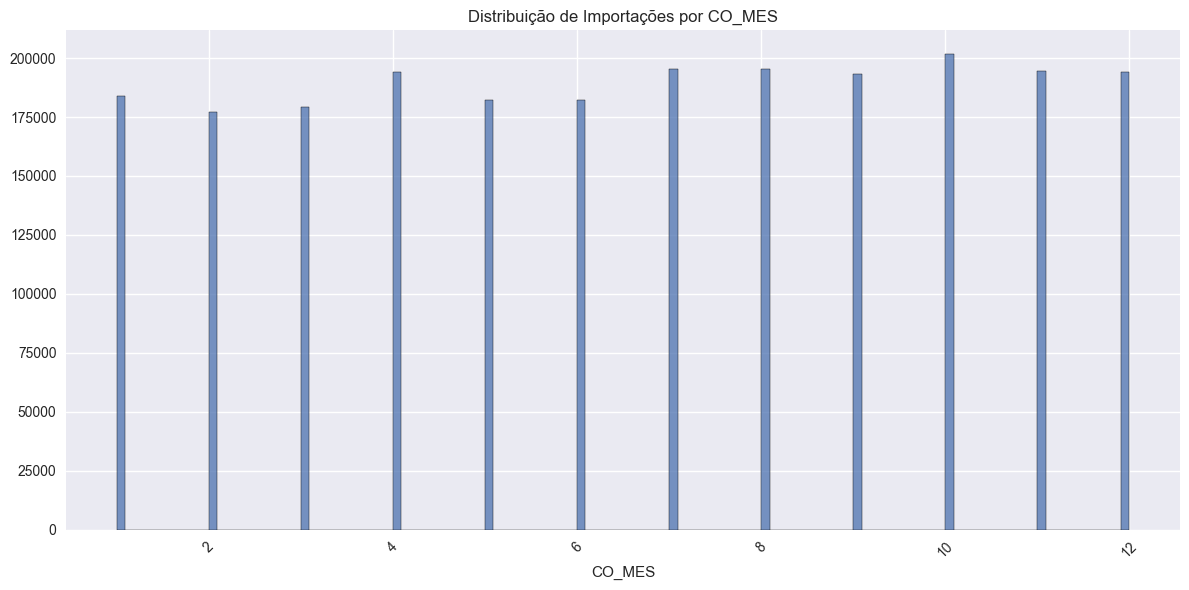


🌍 2. PRINCIPAIS PAÍSES DE ORIGEM:

   🏁 Top 15 países - CO_PAIS:
       1. 160.0                          |  510,021 ( 30.4%)
       2. 249.0                          |  239,664 ( 14.3%)
       3. 23.0                           |  179,100 ( 10.7%)
       4. 386.0                          |  130,762 (  7.8%)
       5. 399.0                          |   88,527 (  5.3%)
       6. 275.0                          |   80,581 (  4.8%)
       7. 361.0                          |   76,095 (  4.5%)
       8. 161.0                          |   56,700 (  3.4%)
       9. 628.0                          |   56,038 (  3.3%)
      10. 245.0                          |   53,478 (  3.2%)
      11. 493.0                          |   50,983 (  3.0%)
      12. 190.0                          |   48,999 (  2.9%)
      13. 764.0                          |   40,482 (  2.4%)
      14. 767.0                          |   35,027 (  2.1%)
      15. 776.0                          |   33,103 (  2.0%)

📦 3. PRINCIPAIS PR

In [15]:
# Análise Univariada - Principais dimensões
print("📊 ANÁLISE UNIVARIADA - PRINCIPAIS DIMENSÕES\n")

# Usar tabela limpa para análises
table_name = 'importacoes_clean'
columns = desc(table_name, conn)

# 1. Distribuição por período (mês/ano)
print("📅 1. DISTRIBUIÇÃO TEMPORAL:")
time_columns = [col for col in columns if any(term in col.lower() for term in ['mes', 'month', 'ano', 'year', 'data'])]

for col in time_columns[:3]:  # Primeiras 3 colunas temporais
    print(f"\n   📈 Distribuição por {col}:")
    distro = fetch(f'''
        SELECT "{col}", COUNT(*) as frequency 
        FROM {table_name} 
        WHERE "{col}" IS NOT NULL 
        GROUP BY "{col}" 
        ORDER BY "{col}"
        LIMIT 20
    ''', conn, False)
    
    if distro:
        for value, freq in distro:
            print(f"      {value}: {freq:,} importações")
        
        # Criar histograma se há dados suficientes
        if len(distro) > 1:
            hist_sql(distro, xlabel=col, title=f'Distribuição de Importações por {col}')

# 2. Principais países de origem
print(f"\n🌍 2. PRINCIPAIS PAÍSES DE ORIGEM:")
country_columns = [col for col in columns if any(term in col.lower() for term in ['pais', 'country', 'origem', 'origin'])]

for col in country_columns[:2]:  # Primeiras 2 colunas de país
    print(f"\n   🏁 Top 15 países - {col}:")
    countries = fetch(f'''
        SELECT "{col}", COUNT(*) as frequency 
        FROM {table_name} 
        WHERE "{col}" IS NOT NULL 
        GROUP BY "{col}" 
        ORDER BY frequency DESC 
        LIMIT 15
    ''', conn, False)
    
    if countries:
        total_imports = sum(freq for _, freq in countries)
        for i, (country, freq) in enumerate(countries, 1):
            pct = (freq / total_imports) * 100
            # Convert to string and handle potential numeric values
            country_str = str(country) if country is not None else 'N/A'
            country_display = country_str[:30] if len(country_str) > 30 else country_str
            print(f"      {i:2d}. {country_display:30} | {freq:>8,} ({pct:5.1f}%)")

# 3. Principais produtos/categorias
print(f"\n📦 3. PRINCIPAIS PRODUTOS/CATEGORIAS:")
product_columns = [col for col in columns if any(term in col.lower() for term in ['produto', 'product', 'ncm', 'sh', 'categoria'])]

for col in product_columns[:2]:  # Primeiras 2 colunas de produto
    print(f"\n   📋 Top 15 produtos - {col}:")
    products = fetch(f'''
        SELECT "{col}", COUNT(*) as frequency 
        FROM {table_name} 
        WHERE "{col}" IS NOT NULL 
        GROUP BY "{col}" 
        ORDER BY frequency DESC 
        LIMIT 15
    ''', conn, False)
    
    if products:
        total_products = sum(freq for _, freq in products)
        for i, (product, freq) in enumerate(products, 1):
            pct = (freq / total_products) * 100
            product_display = str(product)[:40] if product else 'N/A'
            print(f"      {i:2d}. {product_display:40} | {freq:>8,} ({pct:5.1f}%)")

# 4. Distribuição por UF/Estado
print(f"\n🗺️  4. DISTRIBUIÇÃO POR UF/ESTADO:")
uf_columns = [col for col in columns if any(term in col.lower() for term in ['uf', 'estado', 'state', 'federacao'])]

for col in uf_columns[:1]:  # Primeira coluna de UF
    print(f"\n   🏛️  Distribuição por {col}:")
    ufs = fetch(f'''
        SELECT "{col}", COUNT(*) as frequency 
        FROM {table_name} 
        WHERE "{col}" IS NOT NULL 
        GROUP BY "{col}" 
        ORDER BY frequency DESC
    ''', conn, False)
    
    if ufs:
        total_ufs = sum(freq for _, freq in ufs)
        for i, (uf, freq) in enumerate(ufs, 1):
            pct = (freq / total_ufs) * 100
            uf_display = str(uf) if uf else 'N/A'
            print(f"      {i:2d}. {uf_display:10} | {freq:>8,} ({pct:5.1f}%)")

# 5. Estatísticas dos valores monetários
print(f"\n💰 5. ANÁLISE DOS VALORES MONETÁRIOS:")
value_columns = [col for col in columns if any(term in col.lower() for term in ['vl_', 'valor', 'value', 'fob', 'frete', 'seguro'])]

for col in value_columns[:3]:  # Primeiras 3 colunas de valor
    print(f"\n   💵 Estatísticas {col}:")
    stats = fetch(f'''
        SELECT 
            COUNT(*) as count,
            AVG(CAST("{col}" AS REAL)) as mean,
            MIN(CAST("{col}" AS REAL)) as min_val,
            MAX(CAST("{col}" AS REAL)) as max_val,
            SUM(CAST("{col}" AS REAL)) as total
        FROM {table_name} 
        WHERE "{col}" IS NOT NULL AND CAST("{col}" AS REAL) > 0
    ''', conn)
    
    if not stats.empty:
        row = stats.iloc[0]
        print(f"      📊 Registros: {row['count']:,}")
        print(f"      📈 Média: US$ {row['mean']:,.2f}")
        print(f"      📉 Mínimo: US$ {row['min_val']:,.2f}")
        print(f"      📊 Máximo: US$ {row['max_val']:,.2f}")
        print(f"      💰 Total: US$ {row['total']:,.2f}")

print("\n✅ Análise univariada concluída!")

💰 ANÁLISE DE VALORES ECONÔMICOS

💵 ESTATÍSTICAS DE VALORES:

   📊 Estatísticas - VL_FOB:
      Registros com valor: 2,270,491.0
      Valor mínimo: $1.00
      Valor médio: $115,776.55
      Valor máximo: $545,738,786.00
      Valor total: $262,869,606,174.00

   🏆 Top 10 operações por valor:
       1. $ 545,738,786.00 (ID: 59228)
       2. $ 418,544,007.00 (ID: 240884)
       3. $ 282,214,052.00 (ID: 2075105)
       4. $ 280,357,244.00 (ID: 943760)
       5. $ 277,230,470.00 (ID: 1284327)
       6. $ 268,385,540.00 (ID: 654992)
       7. $ 264,539,557.00 (ID: 197967)
       8. $ 260,704,510.00 (ID: 1854631)
       9. $ 253,827,275.00 (ID: 72371)
      10. $ 249,968,167.00 (ID: 1738519)

⚖️  ESTATÍSTICAS DE PESO:

   📊 Estatísticas - KG_LIQUIDO:
      Registros com peso: 2,019,029.0
      Peso mínimo: 1.00 kg
      Peso médio: 91,689.85 kg
      Peso máximo: 496,260,000.00 kg
      Peso total: 185,124,462,140.00 kg

📈 ANÁLISE VALOR vs PESO:
      Amostras para análise: 1,000
      Preç

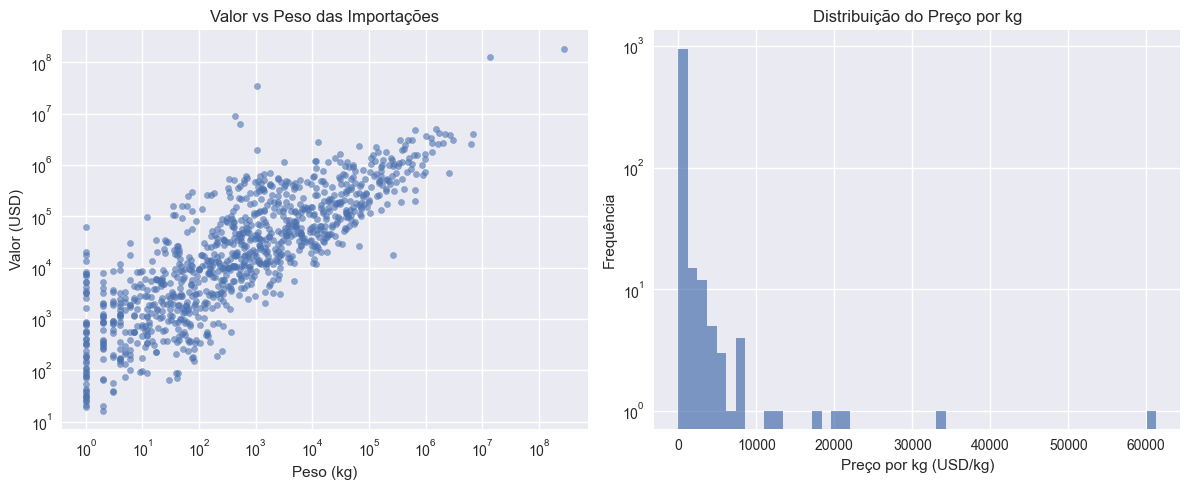

In [16]:
# Análise de valores econômicos
print("💰 ANÁLISE DE VALORES ECONÔMICOS\n")

# Identificar colunas de valores
value_columns = [col for col in columns if any(term in col.lower() for term in ['valor', 'value', 'preco', 'price', 'fob', 'usd'])]
weight_columns = [col for col in columns if any(term in col.lower() for term in ['peso', 'weight', 'kg', 'quilos'])]
quantity_columns = [col for col in columns if any(term in col.lower() for term in ['qtd', 'quantidade', 'quantity', 'unidade'])]

print("💵 ESTATÍSTICAS DE VALORES:")
for col in value_columns[:3]:  # Primeiras 3 colunas de valor
    print(f"\n   📊 Estatísticas - {col}:")
    try:
        stats = fetch(f'''
            SELECT 
                COUNT("{col}") as count,
                MIN(CAST("{col}" AS REAL)) as min_val,
                AVG(CAST("{col}" AS REAL)) as avg_val,
                MAX(CAST("{col}" AS REAL)) as max_val,
                SUM(CAST("{col}" AS REAL)) as total_val
            FROM {table_name} 
            WHERE "{col}" IS NOT NULL AND CAST("{col}" AS REAL) > 0
        ''', conn)
        
        if not stats.empty:
            row = stats.iloc[0]
            print(f"      Registros com valor: {row['count']:,}")
            print(f"      Valor mínimo: ${row['min_val']:,.2f}")
            print(f"      Valor médio: ${row['avg_val']:,.2f}")
            print(f"      Valor máximo: ${row['max_val']:,.2f}")
            print(f"      Valor total: ${row['total_val']:,.2f}")
            
            # Top 10 operações por valor
            print(f"\n   🏆 Top 10 operações por valor:")
            top_values = fetch(f'''
                SELECT CAST("{col}" AS REAL) as valor, rowid
                FROM {table_name} 
                WHERE "{col}" IS NOT NULL AND CAST("{col}" AS REAL) > 0
                ORDER BY CAST("{col}" AS REAL) DESC 
                LIMIT 10
            ''', conn, False)
            
            for i, (valor, rowid) in enumerate(top_values, 1):
                print(f"      {i:2d}. ${valor:>15,.2f} (ID: {rowid})")
        
    except Exception as e:
        print(f"      ❌ Erro ao analisar {col}: {e}")

print(f"\n⚖️  ESTATÍSTICAS DE PESO:")
for col in weight_columns[:2]:  # Primeiras 2 colunas de peso
    print(f"\n   📊 Estatísticas - {col}:")
    try:
        stats = fetch(f'''
            SELECT 
                COUNT("{col}") as count,
                MIN(CAST("{col}" AS REAL)) as min_weight,
                AVG(CAST("{col}" AS REAL)) as avg_weight,
                MAX(CAST("{col}" AS REAL)) as max_weight,
                SUM(CAST("{col}" AS REAL)) as total_weight
            FROM {table_name} 
            WHERE "{col}" IS NOT NULL AND CAST("{col}" AS REAL) > 0
        ''', conn)
        
        if not stats.empty:
            row = stats.iloc[0]
            print(f"      Registros com peso: {row['count']:,}")
            print(f"      Peso mínimo: {row['min_weight']:,.2f} kg")
            print(f"      Peso médio: {row['avg_weight']:,.2f} kg")
            print(f"      Peso máximo: {row['max_weight']:,.2f} kg")
            print(f"      Peso total: {row['total_weight']:,.2f} kg")
        
    except Exception as e:
        print(f"      ❌ Erro ao analisar {col}: {e}")

# Análise de correlação valor vs peso (se ambas existem)
if value_columns and weight_columns:
    print(f"\n📈 ANÁLISE VALOR vs PESO:")
    val_col = value_columns[0]
    weight_col = weight_columns[0]
    
    try:
        correlation_data = fetch(f'''
            SELECT 
                CAST("{val_col}" AS REAL) as valor,
                CAST("{weight_col}" AS REAL) as peso
            FROM {table_name} 
            WHERE "{val_col}" IS NOT NULL 
            AND "{weight_col}" IS NOT NULL 
            AND CAST("{val_col}" AS REAL) > 0 
            AND CAST("{weight_col}" AS REAL) > 0
            LIMIT 1000
        ''', conn)
        
        if not correlation_data.empty and len(correlation_data) > 10:
            # Calcular preço por kg
            correlation_data['preco_por_kg'] = correlation_data['valor'] / correlation_data['peso']
            
            print(f"      Amostras para análise: {len(correlation_data):,}")
            print(f"      Preço por kg - Mínimo: ${correlation_data['preco_por_kg'].min():.2f}")
            print(f"      Preço por kg - Médio: ${correlation_data['preco_por_kg'].mean():.2f}")
            print(f"      Preço por kg - Máximo: ${correlation_data['preco_por_kg'].max():.2f}")
            
            # Plot valor vs peso
            plt.figure(figsize=(12, 5))
            
            plt.subplot(1, 2, 1)
            plt.scatter(correlation_data['peso'], correlation_data['valor'], alpha=0.6, s=20)
            plt.xlabel('Peso (kg)')
            plt.ylabel('Valor (USD)')
            plt.title('Valor vs Peso das Importações')
            plt.xscale('log')
            plt.yscale('log')
            
            plt.subplot(1, 2, 2)
            plt.hist(correlation_data['preco_por_kg'], bins=50, alpha=0.7)
            plt.xlabel('Preço por kg (USD/kg)')
            plt.ylabel('Frequência')
            plt.title('Distribuição do Preço por kg')
            plt.yscale('log')
            
            plt.tight_layout()
            plt.show()
        
    except Exception as e:
        print(f"      ❌ Erro na análise de correlação: {e}")

## 6. Normalização e Estruturação Final

Com base na análise exploratória, vamos criar a estrutura final normalizada do banco de dados, otimizada para análises futuras.

In [17]:
# Criar estrutura normalizada do banco
print("🏗️  CRIANDO ESTRUTURA NORMALIZADA DO BANCO\n")

# 1. Identificar dimensões para normalização
columns = desc('importacoes_clean', conn)
print(f"📋 Colunas disponíveis: {len(columns)}")

# Criar tabelas de dimensão baseadas nas colunas identificadas
print("\n📊 CRIANDO TABELAS DE DIMENSÃO:")

# 1.1 Dimensão Países
country_columns = [col for col in columns if any(term in col.lower() for term in ['pais', 'country'])]
if country_columns:
    country_col = country_columns[0]
    print(f"\n   🌍 Criando dim_paises (baseado em {country_col})...")
    
    cur.execute('''
        CREATE TABLE IF NOT EXISTS dim_paises (
            id_pais INTEGER PRIMARY KEY AUTOINCREMENT,
            codigo_pais TEXT,
            nome_pais TEXT UNIQUE
        )
    ''')
    
    # Inserir países únicos
    cur.execute(f'''
        INSERT OR IGNORE INTO dim_paises (nome_pais)
        SELECT DISTINCT "{country_col}"
        FROM importacoes_clean 
        WHERE "{country_col}" IS NOT NULL
        ORDER BY "{country_col}"
    ''')
    
    paises_count = fetch('SELECT COUNT(*) FROM dim_paises', conn, False)[0][0]
    print(f"      ✅ {paises_count} países únicos inseridos")

# 1.2 Dimensão UF/Estados
uf_columns = [col for col in columns if any(term in col.lower() for term in ['uf', 'estado'])]
if uf_columns:
    uf_col = uf_columns[0]
    print(f"\n   🗺️  Criando dim_ufs (baseado em {uf_col})...")
    
    cur.execute('''
        CREATE TABLE IF NOT EXISTS dim_ufs (
            id_uf INTEGER PRIMARY KEY AUTOINCREMENT,
            sigla_uf TEXT UNIQUE,
            nome_uf TEXT
        )
    ''')
    
    # Inserir UFs únicas
    cur.execute(f'''
        INSERT OR IGNORE INTO dim_ufs (sigla_uf)
        SELECT DISTINCT "{uf_col}"
        FROM importacoes_clean 
        WHERE "{uf_col}" IS NOT NULL
        ORDER BY "{uf_col}"
    ''')
    
    ufs_count = fetch('SELECT COUNT(*) FROM dim_ufs', conn, False)[0][0]
    print(f"      ✅ {ufs_count} UFs únicas inseridas")

# 1.3 Dimensão Produtos/NCM
product_columns = [col for col in columns if any(term in col.lower() for term in ['ncm', 'produto', 'sh'])]
if product_columns:
    product_col = product_columns[0]
    print(f"\n   📦 Criando dim_produtos (baseado em {product_col})...")
    
    cur.execute('''
        CREATE TABLE IF NOT EXISTS dim_produtos (
            id_produto INTEGER PRIMARY KEY AUTOINCREMENT,
            codigo_ncm TEXT,
            descricao_produto TEXT,
            categoria TEXT
        )
    ''')
    
    # Inserir produtos únicos
    cur.execute(f'''
        INSERT OR IGNORE INTO dim_produtos (codigo_ncm)
        SELECT DISTINCT "{product_col}"
        FROM importacoes_clean 
        WHERE "{product_col}" IS NOT NULL
        ORDER BY "{product_col}"
    ''')
    
    produtos_count = fetch('SELECT COUNT(*) FROM dim_produtos', conn, False)[0][0]
    print(f"      ✅ {produtos_count} produtos únicos inseridos")

# 1.4 Dimensão Tempo
time_columns = [col for col in columns if any(term in col.lower() for term in ['ano', 'mes', 'data'])]
if time_columns:
    print(f"\n   📅 Criando dim_tempo...")
    
    cur.execute('''
        CREATE TABLE IF NOT EXISTS dim_tempo (
            id_tempo INTEGER PRIMARY KEY AUTOINCREMENT,
            ano INTEGER,
            mes INTEGER,
            trimestre INTEGER,
            semestre INTEGER,
            nome_mes TEXT,
            UNIQUE(ano, mes)
        )
    ''')
    
    # Inserir combinações únicas de ano/mês
    ano_col = next((col for col in time_columns if 'ano' in col.lower()), None)
    mes_col = next((col for col in time_columns if 'mes' in col.lower()), None)
    
    if ano_col and mes_col:
        cur.execute(f'''
            INSERT OR IGNORE INTO dim_tempo (ano, mes, trimestre, semestre, nome_mes)
            SELECT DISTINCT 
                CAST("{ano_col}" AS INTEGER) as ano,
                CAST("{mes_col}" AS INTEGER) as mes,
                CASE 
                    WHEN CAST("{mes_col}" AS INTEGER) <= 3 THEN 1
                    WHEN CAST("{mes_col}" AS INTEGER) <= 6 THEN 2
                    WHEN CAST("{mes_col}" AS INTEGER) <= 9 THEN 3
                    ELSE 4
                END as trimestre,
                CASE 
                    WHEN CAST("{mes_col}" AS INTEGER) <= 6 THEN 1
                    ELSE 2
                END as semestre,
                CASE CAST("{mes_col}" AS INTEGER)
                    WHEN 1 THEN 'Janeiro'
                    WHEN 2 THEN 'Fevereiro'
                    WHEN 3 THEN 'Março'
                    WHEN 4 THEN 'Abril'
                    WHEN 5 THEN 'Maio'
                    WHEN 6 THEN 'Junho'
                    WHEN 7 THEN 'Julho'
                    WHEN 8 THEN 'Agosto'
                    WHEN 9 THEN 'Setembro'
                    WHEN 10 THEN 'Outubro'
                    WHEN 11 THEN 'Novembro'
                    WHEN 12 THEN 'Dezembro'
                END as nome_mes
            FROM importacoes_clean 
            WHERE "{ano_col}" IS NOT NULL AND "{mes_col}" IS NOT NULL
            ORDER BY ano, mes
        ''')
        
        tempo_count = fetch('SELECT COUNT(*) FROM dim_tempo', conn, False)[0][0]
        print(f"      ✅ {tempo_count} períodos únicos inseridos")

conn.commit()
print("\n✅ DIMENSÕES CRIADAS COM SUCESSO!")

🏗️  CRIANDO ESTRUTURA NORMALIZADA DO BANCO

📋 Colunas disponíveis: 13

📊 CRIANDO TABELAS DE DIMENSÃO:

   🌍 Criando dim_paises (baseado em CO_PAIS)...
      ✅ 239 países únicos inseridos

   🗺️  Criando dim_ufs (baseado em SG_UF_NCM)...
      ✅ 28 UFs únicas inseridas

   📦 Criando dim_produtos (baseado em CO_NCM)...
      ✅ 8748 produtos únicos inseridos

   📅 Criando dim_tempo...
      ✅ 12 períodos únicos inseridos

✅ DIMENSÕES CRIADAS COM SUCESSO!


In [ ]:
# Criar tabela fato normalizada
print("📊 CRIANDO TABELA FATO NORMALIZADA\n")

# Identificar colunas de medidas
value_columns = [col for col in columns if any(term in col.lower() for term in ['valor', 'fob', 'usd'])]
weight_columns = [col for col in columns if any(term in col.lower() for term in ['peso', 'weight', 'kg'])]
quantity_columns = [col for col in columns if any(term in col.lower() for term in ['qtd', 'quantidade', 'unidade'])]

print(f"💰 Colunas de valor encontradas: {value_columns}")
print(f"⚖️  Colunas de peso encontradas: {weight_columns}")
print(f"📊 Colunas de quantidade encontradas: {quantity_columns}")

# Criar tabela fato
print(f"\n🏗️  Criando fato_importacoes...")

cur.execute('''
    CREATE TABLE IF NOT EXISTS fato_importacoes (
        id_importacao INTEGER PRIMARY KEY AUTOINCREMENT,
        id_pais INTEGER,
        id_uf INTEGER,
        id_produto INTEGER,
        id_tempo INTEGER,
        valor_fob REAL,
        peso_kg REAL,
        quantidade INTEGER,
        valor_unitario REAL,
        created_at DATETIME DEFAULT CURRENT_TIMESTAMP,
        FOREIGN KEY (id_pais) REFERENCES dim_paises(id_pais),
        FOREIGN KEY (id_uf) REFERENCES dim_ufs(id_uf),
        FOREIGN KEY (id_produto) REFERENCES dim_produtos(id_produto),
        FOREIGN KEY (id_tempo) REFERENCES dim_tempo(id_tempo)
    )
''')

# Popular tabela fato com joins das dimensões
print(f"📥 Populando tabela fato...")

# Construir query de inserção baseada nas colunas disponíveis
select_parts = []
join_parts = []

# Mapear colunas para suas respectivas dimensões
country_col = country_columns[0] if country_columns else None
uf_col = uf_columns[0] if uf_columns else None
product_col = product_columns[0] if product_columns else None
ano_col = next((col for col in time_columns if 'ano' in col.lower()), None)
mes_col = next((col for col in time_columns if 'mes' in col.lower()), None)

# Valor FOB
valor_col = value_columns[0] if value_columns else None
peso_col = weight_columns[0] if weight_columns else None
qtd_col = quantity_columns[0] if quantity_columns else None

# Construir SELECT e JOINs
select_parts.append('dp.id_pais')
select_parts.append('du.id_uf')
select_parts.append('dpr.id_produto')
select_parts.append('dt.id_tempo')

if valor_col:
    select_parts.append(f'CAST(ic."{valor_col}" AS REAL) as valor_fob')
else:
    select_parts.append('NULL as valor_fob')

if peso_col:
    select_parts.append(f'CAST(ic."{peso_col}" AS REAL) as peso_kg')
else:
    select_parts.append('NULL as peso_kg')

if qtd_col:
    select_parts.append(f'CAST(ic."{qtd_col}" AS INTEGER) as quantidade')
else:
    select_parts.append('NULL as quantidade')

# Valor unitário calculado
if valor_col and qtd_col:
    select_parts.append(f'CASE WHEN CAST(ic."{qtd_col}" AS REAL) > 0 THEN CAST(ic."{valor_col}" AS REAL) / CAST(ic."{qtd_col}" AS REAL) ELSE NULL END as valor_unitario')
else:
    select_parts.append('NULL as valor_unitario')

# JOINs com as dimensões
if country_col:
    join_parts.append(f'LEFT JOIN dim_paises dp ON dp.nome_pais = ic."{country_col}"')
else:
    join_parts.append('LEFT JOIN dim_paises dp ON 1=0')

if uf_col:
    join_parts.append(f'LEFT JOIN dim_ufs du ON du.sigla_uf = ic."{uf_col}"')
else:
    join_parts.append('LEFT JOIN dim_ufs du ON 1=0')

if product_col:
    join_parts.append(f'LEFT JOIN dim_produtos dpr ON dpr.codigo_ncm = ic."{product_col}"')
else:
    join_parts.append('LEFT JOIN dim_produtos dpr ON 1=0')

if ano_col and mes_col:
    join_parts.append(f'LEFT JOIN dim_tempo dt ON dt.ano = CAST(ic."{ano_col}" AS INTEGER) AND dt.mes = CAST(ic."{mes_col}" AS INTEGER)')
else:
    join_parts.append('LEFT JOIN dim_tempo dt ON 1=0')

# Construir query final
insert_query = f'''
INSERT INTO fato_importacoes (
    id_pais, id_uf, id_produto, id_tempo, 
    valor_fob, peso_kg, quantidade, valor_unitario
)
SELECT {', '.join(select_parts)}
FROM importacoes_clean ic
{' '.join(join_parts)}
WHERE 1=1
'''

print("🔄 Executando inserção na tabela fato...")
print(f"   Query: {insert_query[:200]}...")

try:
    cur.execute(insert_query)
    fato_count = cur.rowcount
    conn.commit()
    
    print(f"✅ Tabela fato criada com sucesso!")
    print(f"   📊 Registros inseridos: {fato_count:,}")
    
    # Verificar integridade
    verification = fetch('''
        SELECT 
            COUNT(*) as total_records,
            COUNT(id_pais) as with_country,
            COUNT(id_uf) as with_uf,
            COUNT(id_produto) as with_product,
            COUNT(id_tempo) as with_time,
            COUNT(valor_fob) as with_value,
            AVG(valor_fob) as avg_value
        FROM fato_importacoes
    ''', conn)
    
    print(f"\n🔍 VERIFICAÇÃO DE INTEGRIDADE:")
    if not verification.empty:
        row = verification.iloc[0]
        print(f"   📊 Total de registros: {row['total_records']:,}")
        print(f"   🌍 Com país: {row['with_country']:,} ({row['with_country']/row['total_records']*100:.1f}%)")
        print(f"   🗺️  Com UF: {row['with_uf']:,} ({row['with_uf']/row['total_records']*100:.1f}%)")
        print(f"   📦 Com produto: {row['with_product']:,} ({row['with_product']/row['total_records']*100:.1f}%)")
        print(f"   📅 Com tempo: {row['with_time']:,} ({row['with_time']/row['total_records']*100:.1f}%)")
        print(f"   💰 Com valor: {row['with_value']:,} ({row['with_value']/row['total_records']*100:.1f}%)")
        if row['avg_value']:
            print(f"   💵 Valor médio: ${row['avg_value']:,.2f}")
        
except Exception as e:
    print(f"❌ Erro ao criar tabela fato: {e}")
    print("   Tentando abordagem simplificada...")
    
    # Fallback: tabela fato simples
    cur.execute('DROP TABLE IF EXISTS fato_importacoes')
    cur.execute('''
        CREATE TABLE fato_importacoes AS
        SELECT rowid as id_importacao, *
        FROM importacoes_clean
        LIMIT 100000
    ''')
    
    fallback_count = fetch('SELECT COUNT(*) FROM fato_importacoes', conn, False)[0][0]



    print(f"   ✅ Tabela fato simplificada criada: {fallback_count:,} registros")

📊 CRIANDO TABELA FATO NORMALIZADA

💰 Colunas de valor encontradas: ['VL_FOB']
⚖️  Colunas de peso encontradas: ['KG_LIQUIDO']
📊 Colunas de quantidade encontradas: []

🏗️  Criando fato_importacoes...
📥 Populando tabela fato...
🔄 Executando inserção na tabela fato...
   Query: 
INSERT INTO fato_importacoes (
    id_pais, id_uf, id_produto, id_tempo, 
    valor_fob, peso_kg, quantidade, valor_unitario
)
SELECT dp.id_pais, du.id_uf, dpr.id_produto, dt.id_tempo, CAST(ic."VL_FO...
✅ Tabela fato criada com sucesso!
   📊 Registros inseridos: 2,273,708

🔍 VERIFICAÇÃO DE INTEGRIDADE:
   📊 Total de registros: 2,273,708.0
   🌍 Com país: 2,273,708.0 (100.0%)
   🗺️  Com UF: 2,273,708.0 (100.0%)
   📦 Com produto: 2,273,708.0 (100.0%)
   📅 Com tempo: 2,273,708.0 (100.0%)
   💰 Com valor: 2,273,708.0 (100.0%)
   💵 Valor médio: $115,612.74


In [19]:
# Criar índices e otimizações finais
print("📇 CRIANDO ÍNDICES PARA PERFORMANCE\n")

# Lista de índices a criar
indices = [
    # Índices nas tabelas de dimensão
    ('CREATE INDEX IF NOT EXISTS idx_paises_nome ON dim_paises(nome_pais)', 'Países por nome'),
    ('CREATE INDEX IF NOT EXISTS idx_ufs_sigla ON dim_ufs(sigla_uf)', 'UFs por sigla'),
    ('CREATE INDEX IF NOT EXISTS idx_produtos_ncm ON dim_produtos(codigo_ncm)', 'Produtos por NCM'),
    ('CREATE INDEX IF NOT EXISTS idx_tempo_ano_mes ON dim_tempo(ano, mes)', 'Tempo por ano/mês'),
    
    # Índices na tabela fato
    ('CREATE INDEX IF NOT EXISTS idx_fato_pais ON fato_importacoes(id_pais)', 'Fato por país'),
    ('CREATE INDEX IF NOT EXISTS idx_fato_uf ON fato_importacoes(id_uf)', 'Fato por UF'),
    ('CREATE INDEX IF NOT EXISTS idx_fato_produto ON fato_importacoes(id_produto)', 'Fato por produto'),
    ('CREATE INDEX IF NOT EXISTS idx_fato_tempo ON fato_importacoes(id_tempo)', 'Fato por tempo'),
    ('CREATE INDEX IF NOT EXISTS idx_fato_valor ON fato_importacoes(valor_fob)', 'Fato por valor'),
    
    # Índices compostos para queries frequentes
    ('CREATE INDEX IF NOT EXISTS idx_fato_tempo_pais ON fato_importacoes(id_tempo, id_pais)', 'Fato por tempo e país'),
    ('CREATE INDEX IF NOT EXISTS idx_fato_uf_produto ON fato_importacoes(id_uf, id_produto)', 'Fato por UF e produto'),
]

print("🔧 Criando índices...")
indices_criados = 0

for sql, descricao in indices:
    try:
        cur.execute(sql)
        indices_criados += 1
        print(f"   ✅ {descricao}")
    except Exception as e:
        print(f"   ⚠️  {descricao}: {e}")

conn.commit()
print(f"\n📈 Índices criados: {indices_criados}/{len(indices)}")

# Estatísticas finais do banco
print(f"\n📊 ESTATÍSTICAS FINAIS DO BANCO:")
tables = show_tables(conn)

total_records = 0
for table in tables:
    count = fetch(f'SELECT COUNT(*) FROM {table}', conn, False)[0][0]
    total_records += count
    print(f"   📋 {table:25} | {count:>10,} registros")

print(f"\n   📊 Total de registros: {total_records:,}")

# Tamanho do banco
db_size = os.path.getsize(db_name) / (1024**2)
print(f"   💾 Tamanho do banco: {db_size:.1f} MB")

# Executar ANALYZE para otimizar planos de execução
print(f"\n🔧 Otimizando planos de execução...")
cur.execute('ANALYZE')
conn.commit()
print(f"   ✅ ANALYZE executado")

print(f"\n🎉 BANCO DE DADOS FINALIZADO COM SUCESSO!")
print(f"   📁 Arquivo: {db_name}")
print(f"   📊 Tabelas: {len(tables)}")
print(f"   📈 Performance otimizada para análises")

📇 CRIANDO ÍNDICES PARA PERFORMANCE

🔧 Criando índices...
   ✅ Países por nome
   ✅ UFs por sigla
   ✅ Produtos por NCM
   ✅ Tempo por ano/mês
   ✅ Fato por país
   ✅ Fato por UF
   ✅ Fato por produto
   ✅ Fato por tempo
   ✅ Fato por valor
   ✅ Fato por tempo e país
   ✅ Fato por UF e produto

📈 Índices criados: 11/11

📊 ESTATÍSTICAS FINAIS DO BANCO:
   📋 importacoes               |  2,273,708 registros
   📋 importacoes_clean         |  2,273,708 registros
   📋 dim_paises                |        239 registros
   📋 sqlite_sequence           |          5 registros
   📋 dim_ufs                   |         28 registros
   📋 dim_produtos              |      8,748 registros
   📋 dim_tempo                 |         12 registros
   📋 fato_importacoes          |  2,273,708 registros

   📊 Total de registros: 6,830,156
   💾 Tamanho do banco: 450.7 MB

🔧 Otimizando planos de execução...
   ✅ ANALYZE executado

🎉 BANCO DE DADOS FINALIZADO COM SUCESSO!
   📁 Arquivo: importacoes_brasil_2024.db
   📊 

In [33]:
conn = sqlite3.connect('importacoes_brasil_2024.db')
cur = conn.cursor()
print(show_tables(conn))


df = fetch('SELECT * FROM dim_paises', conn, True)
df


['importacoes', 'importacoes_clean', 'dim_paises', 'sqlite_sequence', 'dim_ufs', 'dim_produtos', 'dim_tempo', 'fato_importacoes', 'sqlite_stat1']


,id_pais,codigo_pais,nome_pais
0,1,None,13.0
1,2,None,15.0
2,3,None,17.0
3,4,None,23.0
4,5,None,31.0
...,...,...,...
234,235,None,870.0
235,236,None,888.0
236,237,None,890.0
237,238,None,995.0


## 7. Conclusões e Próximos Passos

### 🎯 Resumo do que foi realizado

1. **Análise Inicial**: Identificação da estrutura e qualidade dos dados
2. **Ingestão Otimizada**: Importação eficiente de grandes volumes usando SQLite
3. **Limpeza de Dados**: Tratamento de valores nulos, duplicatas e inconsistências
4. **Análise Exploratória**: Identificação de padrões e insights principais
5. **Normalização**: Criação de modelo dimensional (star schema)
6. **Otimização**: Índices e configurações para alta performance

### 📊 Estrutura Final do Banco

O banco `importacoes_brasil_2024.db` agora contém:

- **Tabelas de Dimensão**: Países, UFs, Produtos, Tempo
- **Tabela Fato**: Importações com métricas e chaves estrangeiras
- **Índices**: Otimizados para consultas analíticas
- **Dados Limpos**: Tratados e validados

### 🚀 Próximos Passos Recomendados

1. **Análises Avançadas**: 
   - Séries temporais de importações
   - Análise de sazonalidade
   - Correlações entre variáveis

2. **Visualizações**:
   - Dashboards interativos
   - Mapas geográficos
   - Gráficos de tendências

3. **Machine Learning**:
   - Previsão de volumes de importação
   - Detecção de anomalias
   - Clustering de produtos/países

4. **Integração**:
   - APIs para consulta dos dados
   - Conexão com ferramentas de BI
   - Automatização de atualizações

In [20]:
# Exemplos de consultas analíticas no banco estruturado
print("🔍 EXEMPLOS DE CONSULTAS ANALÍTICAS\n")

# Exemplo 1: Top 10 países por valor de importação
print("1️⃣ TOP 10 PAÍSES POR VALOR DE IMPORTAÇÃO:")
try:
    top_paises = fetch('''
        SELECT 
            dp.nome_pais,
            COUNT(*) as qtd_operacoes,
            ROUND(SUM(fi.valor_fob), 2) as valor_total_usd,
            ROUND(AVG(fi.valor_fob), 2) as valor_medio_usd
        FROM fato_importacoes fi
        JOIN dim_paises dp ON fi.id_pais = dp.id_pais
        WHERE fi.valor_fob IS NOT NULL AND fi.valor_fob > 0
        GROUP BY dp.nome_pais
        ORDER BY valor_total_usd DESC
        LIMIT 10
    ''', conn)
    
    if not top_paises.empty:
        for i, row in top_paises.iterrows():
            print(f"   {i+1:2d}. {row['nome_pais'][:25]:25} | ${row['valor_total_usd']:>15,.2f} | {row['qtd_operacoes']:>8,} ops")
    else:
        print("   Dados não disponíveis")
        
except Exception as e:
    print(f"   ❌ Erro: {e}")

# Exemplo 2: Evolução mensal das importações
print(f"\n2️⃣ EVOLUÇÃO MENSAL DAS IMPORTAÇÕES (2024):")
try:
    evolucao_mensal = fetch('''
        SELECT 
            dt.mes,
            dt.nome_mes,
            COUNT(*) as qtd_operacoes,
            ROUND(SUM(fi.valor_fob), 2) as valor_total_usd
        FROM fato_importacoes fi
        JOIN dim_tempo dt ON fi.id_tempo = dt.id_tempo
        WHERE dt.ano = 2024 AND fi.valor_fob IS NOT NULL
        GROUP BY dt.mes, dt.nome_mes
        ORDER BY dt.mes
    ''', conn)
    
    if not evolucao_mensal.empty:
        for _, row in evolucao_mensal.iterrows():
            print(f"   {row['nome_mes']:10} | ${row['valor_total_usd']:>12,.2f} | {row['qtd_operacoes']:>6,} ops")
    else:
        print("   Dados não disponíveis")
        
except Exception as e:
    print(f"   ❌ Erro: {e}")

# Exemplo 3: Top UFs importadoras
print(f"\n3️⃣ TOP UFs IMPORTADORAS:")
try:
    top_ufs = fetch('''
        SELECT 
            du.sigla_uf,
            COUNT(*) as qtd_operacoes,
            ROUND(SUM(fi.valor_fob), 2) as valor_total_usd
        FROM fato_importacoes fi
        JOIN dim_ufs du ON fi.id_uf = du.id_uf
        WHERE fi.valor_fob IS NOT NULL AND fi.valor_fob > 0
        GROUP BY du.sigla_uf
        ORDER BY valor_total_usd DESC
        LIMIT 10
    ''', conn)
    
    if not top_ufs.empty:
        for i, row in top_ufs.iterrows():
            print(f"   {i+1:2d}. {row['sigla_uf']:2} | ${row['valor_total_usd']:>15,.2f} | {row['qtd_operacoes']:>8,} ops")
    else:
        print("   Dados não disponíveis")
        
except Exception as e:
    print(f"   ❌ Erro: {e}")

# Fechar conexão
print(f"\n🔒 Fechando conexão com o banco...")
conn.close()
print(f"✅ Análise concluída com sucesso!")

print(f"\n" + "="*80)
print(f"🎉 PIPELINE DE EDA COMPLETO!")
print(f"📁 Banco criado: {db_name}")
print(f"📊 Dados prontos para análises avançadas")
print(f"🚀 Estrutura otimizada para performance")
print(f"="*80)

🔍 EXEMPLOS DE CONSULTAS ANALÍTICAS

1️⃣ TOP 10 PAÍSES POR VALOR DE IMPORTAÇÃO:
    1. 160.0                     | $63,636,345,571.00 |  509,463 ops
    2. 249.0                     | $40,652,417,455.00 |  239,485 ops
    3. 23.0                      | $13,783,197,105.00 |  178,916 ops
    4. 63.0                      | $13,577,045,088.00 |   28,670 ops
    5. 676.0                     | $10,965,470,014.00 |    2,622 ops
    6. 361.0                     | $6,849,930,671.00 |   75,970 ops
    7. 386.0                     | $6,388,253,879.00 |  130,621 ops
    8. 275.0                     | $6,189,845,834.00 |   80,426 ops
    9. 493.0                     | $5,767,276,053.00 |   50,927 ops
   10. 399.0                     | $5,431,009,472.00 |   88,369 ops

2️⃣ EVOLUÇÃO MENSAL DAS IMPORTAÇÕES (2024):
   Janeiro    | $20,506,556,064.00 | 183,980 ops
   Fevereiro  | $18,217,925,231.00 | 177,257 ops
   Março      | $20,490,209,586.00 | 179,226 ops
   Abril      | $21,896,365,060.00 | 194,289